<a href="https://colab.research.google.com/github/inamoorata/PCD_Assigment1/blob/main/PCD_Assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [26]:
def max_downsample (image, block_size=2):
  tinggi, lebar, channel = image.shape
  newTinggi, newLebar = tinggi//block_size, lebar//block_size
  output = np.zeros((newTinggi, newLebar, channel), dtype=np.uint8)
  for i in range (newTinggi):
    for j in range (newLebar):
      block = image[i*block_size:(i+1)*block_size, j*block_size:(j+1)*block_size]
      output[i,j]=np.max(block, axis=(0,1))
  return output

In [27]:
def avg_downsample (image, block_size=2):
  tinggi, lebar, channel = image.shape
  newTinggi, newLebar = tinggi//block_size, lebar//block_size
  output = np.zeros((newTinggi, newLebar, channel), dtype=np.uint8)
  for i in range (newTinggi):
    for j in range (newLebar):
      block = image[i*block_size:(i+1)*block_size, j*block_size:(j+1)*block_size]
      output[i,j]=np.mean(block, axis=(0,1))
  return output

In [28]:
def median_downsample (image, block_size=2):
  tinggi, lebar, channel = image.shape
  newTinggi, newLebar = tinggi//block_size, lebar//block_size
  output = np.zeros((newTinggi, newLebar, channel), dtype=np.uint8)
  for i in range (newTinggi):
    for j in range (newLebar):
      block = image[i*block_size:(i+1)*block_size, j*block_size:(j+1)*block_size]
      output[i,j]=np.median(block, axis=(0,1))
  return output

In [29]:
def nn_upsample (image, scale=2):
  tinggi, lebar, channel = image.shape
  newTinggi, newLebar = tinggi*scale, lebar*scale
  output = np.zeros((newTinggi, newLebar, channel), dtype=np.uint8)
  for i in range (newTinggi):
    for j in range (newLebar):
      output[i,j]=image[i//scale, j//scale]
  return output

In [30]:
def bilinear_upsample (image, scale=2):
  tinggi, lebar, channel = image.shape
  newTinggi, newLebar = tinggi*scale, lebar*scale
  output = np.zeros((newTinggi, newLebar, channel), dtype=np.float32)
  for i in range (newTinggi):
    for j in range (newLebar):
      # mencari posisi koordinat di gambar asli
      x_asli, y_asli = j/scale, i/scale
      x1, y1 = int(x_asli), int(y_asli)
      x2, y2 = min(x1+1, lebar-1), min(y1+1, tinggi-1)

      # menghitung jarak desimalnya
      dx, dy=x_asli-x1, y_asli-y1
      # menghitung average warna batas atas dn bawah
      top=(1-dx) * image[y1,x1] + dx * image[y1,x2]
      bottom= (1-dx) * image[y2,x1] + dx * image[y2,x2]

      output[i,j]=(1-dy) * top + dy * bottom
  return np.clip(output, 0, 255).astype(np.uint8)

In [31]:
def cubic_weight(x, a=-0.5): #-0,5 nilai standar utk ketajaman garis
    x = abs(x)
    if x <= 1:
        return (a + 2) * (x**3) - (a + 3) * (x**2) + 1
    elif 1 < x < 2:
        return a * (x**3) - 5 * a * (x**2) + 8 * a * x - 4 * a
    return 0

def bicubic_upsample(image, scale=2):
    tinggi, lebar, channel = image.shape
    newTinggi, newLebar = tinggi * scale, lebar * scale
    output = np.zeros((newTinggi, newLebar, channel), dtype=np.float32)

    for i in range(newTinggi):
        for j in range(newLebar):
            orig_x, orig_y = j / scale, i / scale
            x_int, y_int = int(orig_x), int(orig_y)

            val = np.zeros(channel)
            #menyisir area 4x4 piksel di sekitar titik pusat
            for m in range(-1, 3):
                for n in range(-1, 3):
                    #kunci koordinat agar tak keluar batas gambar
                    px = min(max(x_int + m, 0), lebar - 1)
                    py = min(max(y_int + n, 0), tinggi - 1)

                    #hitung bobot berdasarkan jarak titik
                    weight_x = cubic_weight(orig_x - (x_int + m))
                    weight_y = cubic_weight(orig_y - (y_int + n))

                    #akumulasi nilai pxel x bobot
                    val += image[py, px] * weight_x * weight_y

            output[i, j] = val

    return np.clip(output, 0, 255).astype(np.uint8)

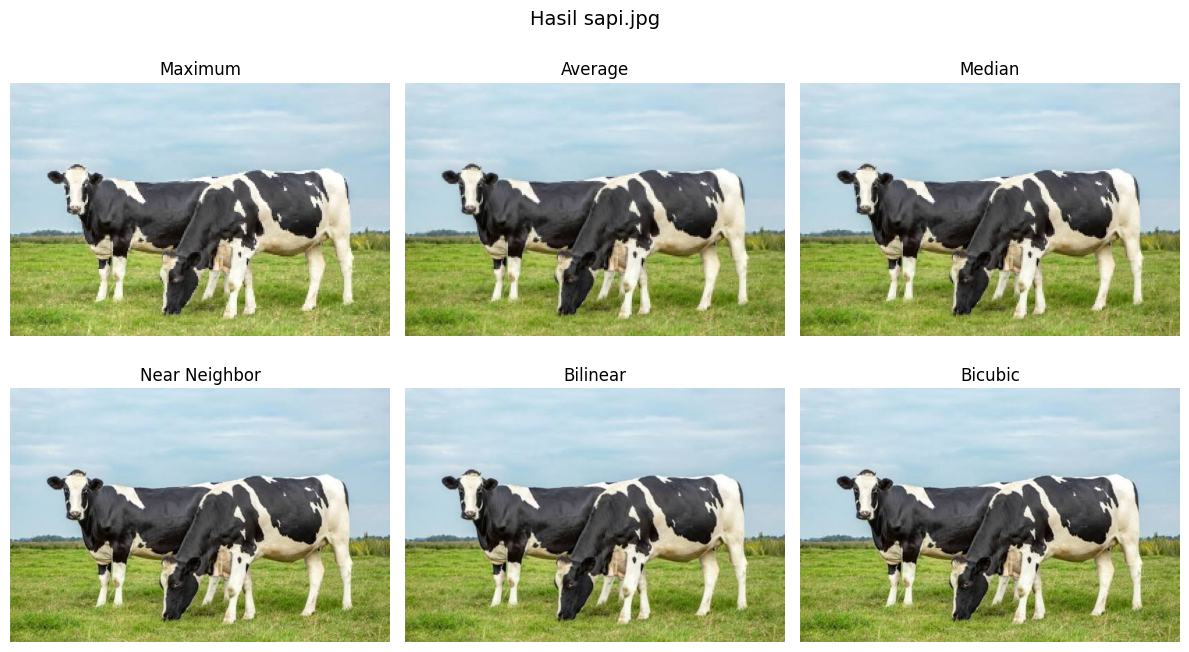

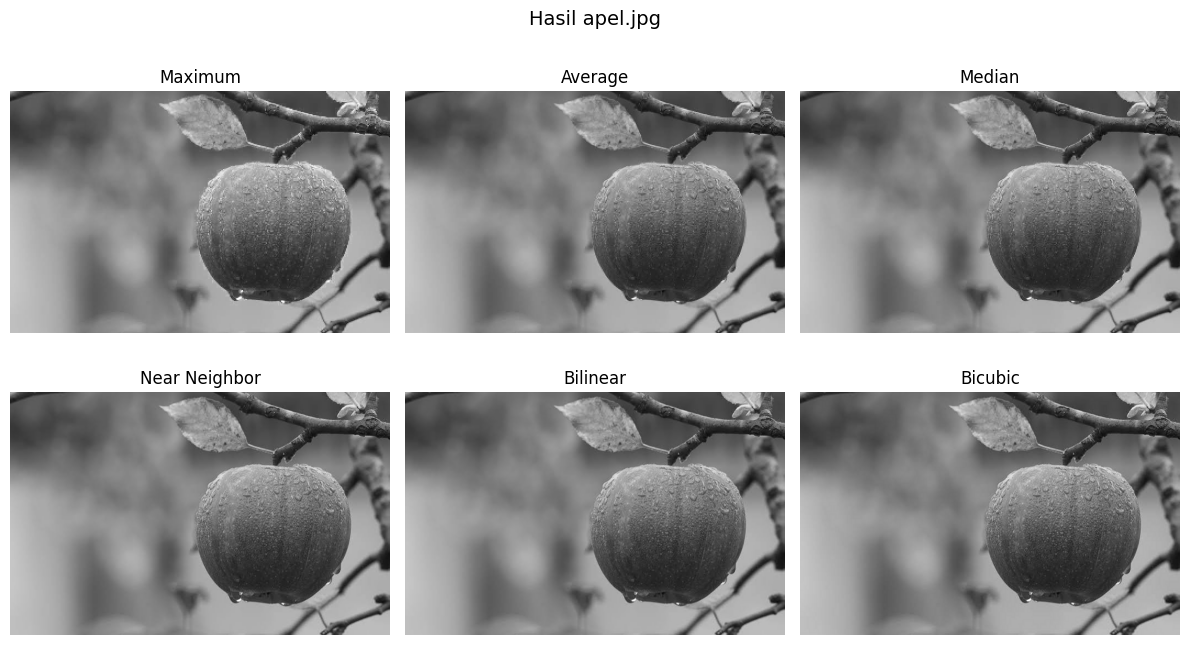

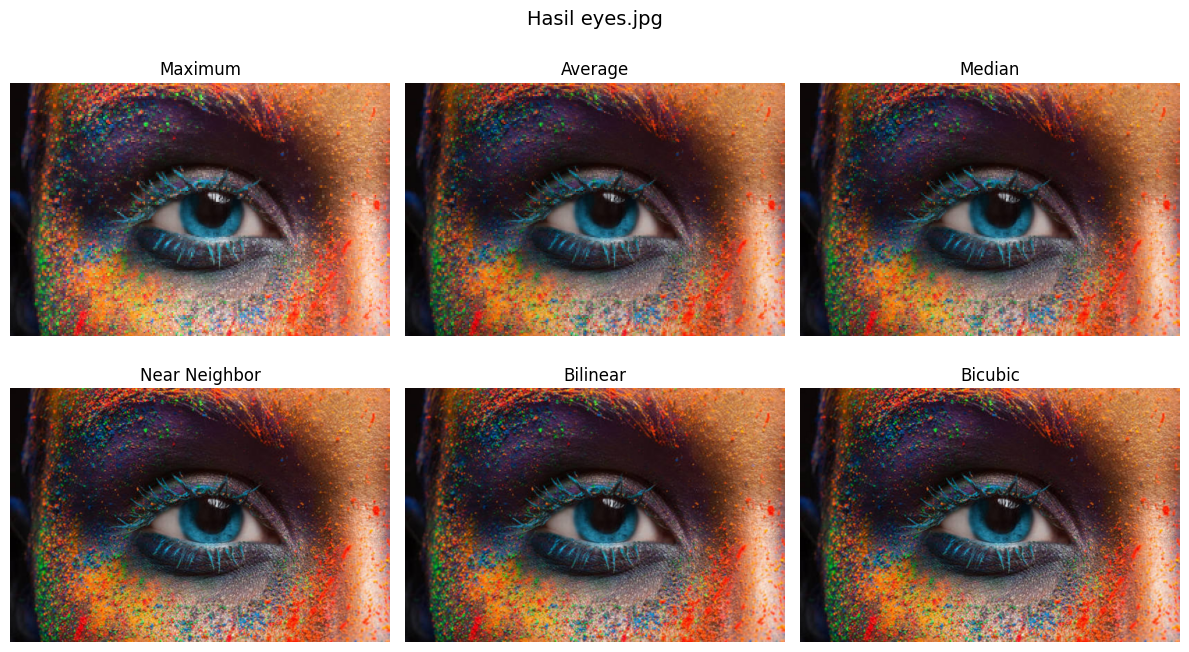

In [38]:
gambar = ['sapi.jpg', 'apel.jpg', 'eyes.jpg']

for imgName in gambar:
  imgBGR = cv2.imread(imgName)
  if imgBGR is None:
        print(f"File '{imgName}' tidak ditemukan atau gagal dibaca!")
        continue
  img = cv2.cvtColor(imgBGR, cv2.COLOR_BGR2RGB)

  ds_max = max_downsample (img)
  ds_avg = avg_downsample (img)
  ds_med = median_downsample (img)

  us_nn = nn_upsample (img)
  us_bilinear = bilinear_upsample (img)
  us_bicubic = bicubic_upsample (img)

  plt.figure(figsize=(12, 7))
  plt.suptitle(f"Hasil {imgName}", fontsize=14)

  # downsampling
  plt.subplot(2, 3, 1); plt.imshow(ds_max); plt.title("Maximum"); plt.axis('off')
  plt.subplot(2, 3, 2); plt.imshow(ds_avg); plt.title("Average"); plt.axis('off')
  plt.subplot(2, 3, 3); plt.imshow(ds_med); plt.title("Median"); plt.axis('off')

  # upsampling
  plt.subplot(2, 3, 4); plt.imshow(us_nn); plt.title("Near Neighbor"); plt.axis('off')
  plt.subplot(2, 3, 5); plt.imshow(us_bilinear); plt.title("Bilinear"); plt.axis('off')
  plt.subplot(2, 3, 6); plt.imshow(us_bicubic); plt.title("Bicubic"); plt.axis('off')

  plt.tight_layout()
  plt.show()